# Diffusion

In [1]:
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128

import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import math
import os
from tqdm import tqdm
from datetime import datetime

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'using {device}')

using cuda


## Forward Process

The forward process gradually destroys an image by adding Gaussian noise over $T$ timesteps. At each step:

$$q(x_t \mid x_{t-1}) = \mathcal{N}\!\left(x_t;\ \sqrt{1-\beta_t}\, x_{t-1},\ \beta_t \mathbf{I}\right)$$

Marginalizing over intermediate steps gives a closed form for sampling at any $t$ directly:

$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \mathbf{I})$$

where $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$.

CIFAR-10 contains 60,000 32×32 RGB photographs across 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. Unlike MNIST, images have three color channels and far more visual variation — the forward process is otherwise identical.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset    = torchvision.datasets.CIFAR10(root='data', train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

In [4]:
T          = 1000
betas      = torch.linspace(1e-4, 0.02, T).to(device)
alphas     = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def forward(x0, t):
    ab  = alpha_bars[t].view(-1, 1, 1, 1)
    eps = torch.randn_like(x0)
    xt  = ab.sqrt() * x0 + (1 - ab).sqrt() * eps
    return xt, eps

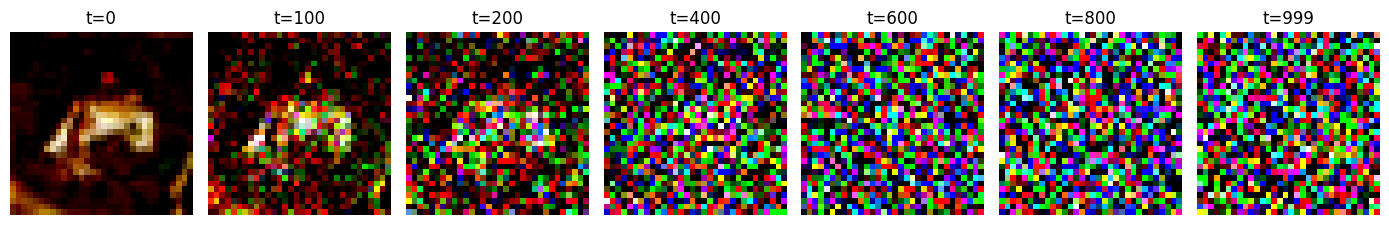

In [5]:
x0, _ = dataset[0]
x0 = x0.to(device)
timesteps = [0, 100, 200, 400, 600, 800, 999]

fig, axes = plt.subplots(1, len(timesteps), figsize=(14, 3))
for ax, t in zip(axes, timesteps):
    xt, _ = forward(x0.unsqueeze(0), torch.tensor([t], device=device))
    ax.imshow(xt.squeeze().cpu().permute(1, 2, 0).clamp(0, 1))
    ax.set_title(f't={t}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## UNet

The UNet is our $\varepsilon_\theta(x_t, t)$ — it takes a noisy image and a timestep and predicts the noise.

Architecture:
- **Encoder**: series of blocks that downsample, each increasing channel depth
- **Bottleneck**: deepest representation, no spatial change
- **Decoder**: series of blocks that upsample, each receiving the corresponding encoder skip
- **Time embedding**: sinusoidal encoding of $t$, projected and injected into every block

### Time Embedding

Sinusoidal encoding maps scalar $t$ to a vector, same formula as transformer positional encodings:

$$\text{emb}_{2i} = \sin\left(\frac{t}{10000^{2i/d}}\right), \quad \text{emb}_{2i+1} = \cos\left(\frac{t}{10000^{2i/d}}\right)$$

The encoding is fixed; a learned MLP then projects it to match each block's channel dimension.

In [6]:
def sinusoidal_embedding(t, dim):
    # t: (B,) integer timesteps, dim: embedding size
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
    args = t[:, None].float() * freqs[None]
    return torch.cat([args.sin(), args.cos()], dim=-1)  # (B, dim)

### Basic Block

Each block: two convolutions with GroupNorm and ReLU, plus time injection.

Time is added after the first conv — projected to match channel depth, then broadcast spatially.

In [7]:
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.act   = nn.ReLU()
        self.time_proj = nn.Linear(time_dim, out_ch)

    def forward(self, x, t_emb):
        x = self.act(self.norm1(self.conv1(x)))
        x = x + self.time_proj(t_emb)[:, :, None, None]  # broadcast over H, W
        x = self.act(self.norm2(self.conv2(x)))
        return x

### UNet

The encoder path halves spatial resolution at each stage while doubling channels, building an increasingly abstract representation. The decoder path reverses this, with skip connections from the corresponding encoder stage concatenated at each level — these carry fine spatial detail that the bottleneck representation has lost. The final 1×1 convolution projects back to the input channel count.

In [8]:
class UNet(nn.Module):
    def __init__(self, in_ch=3, base_ch=64, time_dim=128, n_labels=10):
        super().__init__()
        self.time_dim = time_dim
        self.n_labels = n_labels
        
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim * 4),
            nn.ReLU(),
            nn.Linear(time_dim * 4, time_dim),
        )
        
        self.label_emb = nn.Embedding(n_labels, time_dim)

        # encoder
        self.enc1 = Block(in_ch,      base_ch,     time_dim)
        self.enc2 = Block(base_ch,    base_ch * 2, time_dim)
        self.enc3 = Block(base_ch*2,  base_ch * 4, time_dim)
        self.down  = nn.MaxPool2d(2)

        # bottleneck
        self.bot   = Block(base_ch*4, base_ch * 4, time_dim)

        # decoder — in_ch doubles because of skip concatenation
        self.up    = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec3  = Block(base_ch*4 + base_ch*4, base_ch * 2, time_dim)
        self.dec2  = Block(base_ch*2 + base_ch*2, base_ch,     time_dim)
        self.dec1  = Block(base_ch   + base_ch,   base_ch,     time_dim)

        self.out   = nn.Conv2d(base_ch, in_ch, 1)

    def forward(self, x, t, label):
        H, W = x.shape[2], x.shape[3]
        pad_h = (8 - H % 8) % 8
        pad_w = (8 - W % 8) % 8
        x = torch.nn.functional.pad(x, (0, pad_w, 0, pad_h))

        t_emb = self.time_mlp(sinusoidal_embedding(t, self.time_dim))
        l_emb = self.label_emb(label)
        t_emb += l_emb

        s1 = self.enc1(x,             t_emb)
        s2 = self.enc2(self.down(s1), t_emb)
        s3 = self.enc3(self.down(s2), t_emb)

        b  = self.bot(self.down(s3),  t_emb)

        x  = self.dec3(torch.cat([self.up(b),  s3], dim=1), t_emb)
        x  = self.dec2(torch.cat([self.up(x),  s2], dim=1), t_emb)
        x  = self.dec1(torch.cat([self.up(x),  s1], dim=1), t_emb)

        x  = self.out(x)
        return x[:, :, :H, :W]

## Sampling (Reverse Diffusion)

Generation runs the reverse chain: start from $x_T \sim \mathcal{N}(0, \mathbf{I})$ and denoise step by step down to $x_0$.

### Reverse Posterior Derivation

We want $q(x_{t-1} \mid x_t, x_0)$. By Bayes:

$$q(x_{t-1} \mid x_t, x_0) \propto q(x_t \mid x_{t-1})\, q(x_{t-1} \mid x_0)$$

The denominator $q(x_t \mid x_0)$ has no $x_{t-1}$ in it — constant, folds into normalization.

Each term is a Gaussian over $\mathbb{R}^{C \times H \times W}$ (image treated as a flat vector); the squared terms are $\|\cdot\|^2$, summed over all components. We only need the exponents:

$$q(x_t \mid x_{t-1}) \propto \exp\!\left(-\frac{\|x_t - \sqrt{\alpha_t}\,x_{t-1}\|^2}{2\beta_t}\right)$$

$$q(x_{t-1} \mid x_0) \propto \exp\!\left(-\frac{\|x_{t-1} - \sqrt{\bar{\alpha}_{t-1}}\,x_0\|^2}{2(1-\bar{\alpha}_{t-1})}\right)$$

Add the exponents and collect by powers of $x_{t-1}$:

$$\propto -\frac{1}{2}\left[\left(\frac{\alpha_t}{\beta_t} + \frac{1}{1-\bar{\alpha}_{t-1}}\right)\|x_{t-1}\|^2 - 2\left(\frac{\sqrt{\alpha_t}}{\beta_t}x_t + \frac{\sqrt{\bar{\alpha}_{t-1}}}{1-\bar{\alpha}_{t-1}}x_0\right)\cdot x_{t-1}\right]$$

This is a quadratic in $x_{t-1}$, so it's a Gaussian. Match to $-\frac{1}{2\tilde{\beta}_t}\|x_{t-1} - \tilde{\mu}_t\|^2$:

**Variance:**

$$\frac{1}{\tilde{\beta}_t} = \frac{\alpha_t}{\beta_t} + \frac{1}{1-\bar{\alpha}_{t-1}} = \frac{1-\bar{\alpha}_t}{\beta_t(1-\bar{\alpha}_{t-1})} \quad\Rightarrow\quad \boxed{\tilde{\beta}_t = \frac{\beta_t\,(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}}$$

**Mean:**

$$\frac{\tilde{\mu}_t}{\tilde{\beta}_t} = \frac{\sqrt{\alpha_t}}{\beta_t}x_t + \frac{\sqrt{\bar{\alpha}_{t-1}}}{1-\bar{\alpha}_{t-1}}x_0 \quad\Rightarrow\quad \boxed{\tilde{\mu}_t = \frac{\sqrt{\bar{\alpha}_{t-1}}\,\beta_t}{1-\bar{\alpha}_t}\,x_0 + \frac{\sqrt{\alpha_t}\,(1-\bar{\alpha}_{t-1})}{1-\bar{\alpha}_t}\,x_t}$$

At generation time, substitute $\hat{x}_0 = \frac{x_t - \sqrt{1-\bar{\alpha}_t}\,\varepsilon_\theta}{\sqrt{\bar{\alpha}_t}}$ since $x_0$ is unknown.

**Sample** via reparametrization: $x_{t-1} = \tilde{\mu}_t + \sqrt{\tilde{\beta}_t}\,\varepsilon,\quad \varepsilon \sim \mathcal{N}(0,\mathbf{I})$

*(At $t=1$, $\tilde{\beta}_t \to 0$ so we skip the noise term and return $\tilde{\mu}_t$ directly.)*

In [9]:
@torch.no_grad()
def sample(model, labels, image_size=(3, 32, 32)):
    model.eval()
    n = labels.shape[0]
    C, H, W = image_size
    xt = torch.randn(n, C, H, W, device=device)
    for t in tqdm(reversed(range(T)), total=T, desc='sampling'):
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)
        ab      = alpha_bars[t]
        ab_prev = alpha_bars[t - 1] if t > 0 else torch.tensor(1.0, device=device)
        beta    = betas[t]
        alpha   = alphas[t]
        eps_pred = model(xt, t_batch, labels)
        x0_hat   = (xt - (1 - ab).sqrt() * eps_pred) / ab.sqrt()
        x0_hat   = x0_hat.clamp(-1, 1)
        mu  = (ab_prev.sqrt() * beta / (1 - ab)) * x0_hat \
            + (alpha.sqrt() * (1 - ab_prev) / (1 - ab)) * xt
        var = beta * (1 - ab_prev) / (1 - ab)
        noise = torch.randn_like(xt) if t > 0 else torch.zeros_like(xt)
        xt    = mu + var.sqrt() * noise
    return xt

## Training

The training loop is straightforward:

1. Sample a real image $x_0$
2. Sample a random timestep $t$
3. Sample noise $\varepsilon \sim \mathcal{N}(0, \mathbf{I})$
4. Compute $x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1-\bar{\alpha}_t}\, \varepsilon$
5. Predict $\varepsilon_\theta(x_t, t)$
6. Minimize $\|\varepsilon - \varepsilon_\theta\|^2$

### Data

Images are normalized to $[-1, 1]$ — the model outputs noise in this range, and the clamp in the sampling loop assumes it. CIFAR-10 has per-channel means and stds close to 0.5, so a uniform $(0.5, 0.5, 0.5)$ normalization is a reasonable approximation.

In [10]:
model     = UNet(in_ch=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5, min_lr=1e-5)
loss_fn   = nn.MSELoss()

In [11]:
import os
if os.path.exists('data/unet_cifar10_large_latest.pt'):
    model.load_state_dict(torch.load('data/unet_cifar10_large_latest.pt', map_location=device))
    print('loaded checkpoint')
else:
    print('no checkpoint found, training from scratch')

loaded checkpoint


In [ ]:
max_epochs   = 200
patience     = 10
min_delta    = 1e-4
best_loss    = float('inf')
no_improve   = 0
losses       = []

for epoch in range(max_epochs):
    epoch_loss = 0.0
    pbar = tqdm(dataloader, desc=f'epoch {epoch+1}', leave=False)
    for x0, labels in pbar:
        x0       = x0.to(device)
        labels   = labels.to(device)
        t        = torch.randint(0, T, (x0.shape[0],), device=device)
        xt, eps  = forward(x0, t)
        eps_pred = model(xt, t, labels)
        loss     = loss_fn(eps_pred, eps)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    avg = epoch_loss / len(dataloader)
    losses.append(avg)
    scheduler.step(avg)
    lr = optimizer.param_groups[0]['lr']
    print(f'epoch {epoch+1:3d}  loss {avg:.4f}  lr {lr:.2e}')

    if avg < best_loss - min_delta:
        best_loss  = avg
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'converged at epoch {epoch+1}')
            break

from datetime import datetime
ts = datetime.now().strftime('%Y%m%d_%H%M')
torch.save(model.cpu().state_dict(), f'data/unet_cifar10_large_{ts}.pt')
torch.save(model.cpu().state_dict(), 'data/unet_cifar10_large_latest.pt')
model.to(device)
print(f'saved unet_cifar10_large_{ts}.pt')

plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

sampling: 100%|██████████| 1000/1000 [00:12<00:00, 79.55it/s]


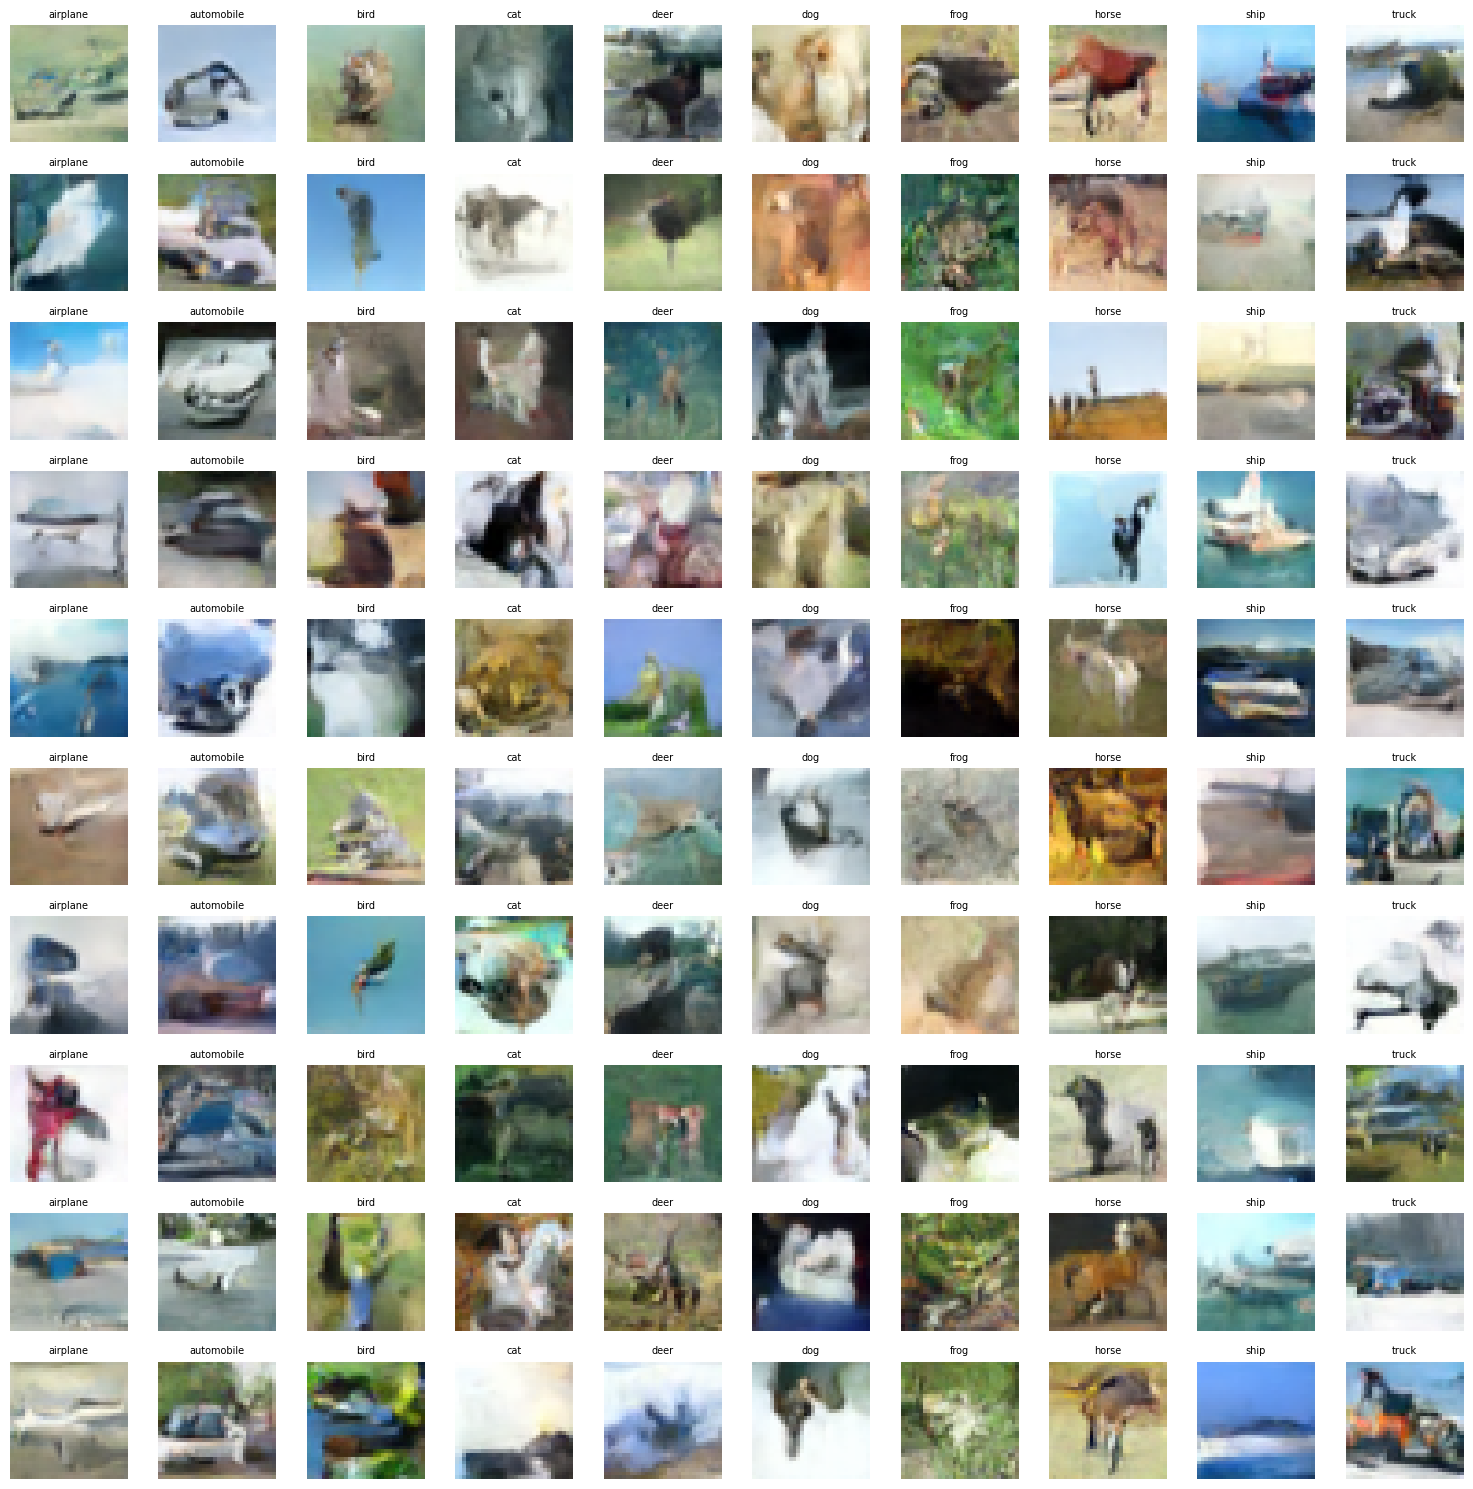

UNet(
  (time_mlp): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
  )
  (label_emb): Embedding(10, 128)
  (enc1): Block(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (act): ReLU()
    (time_proj): Linear(in_features=128, out_features=64, bias=True)
  )
  (enc2): Block(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
    (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
    (act): ReLU()
    (time_proj): Linear(in_features=128, out_features=128, bias=True)
  )
  (enc3): Block(
    (conv1): Conv2d(

In [13]:
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

n = 10
labels = torch.arange(10, dtype=torch.long, device=device).repeat(n)
images = sample(model, labels)
images = (images + 1) / 2

fig, axes = plt.subplots(n, 10, figsize=(15, n * 1.5))
for ax, img, label in zip(axes.flat, images, labels):
    ax.imshow(img.cpu().permute(1, 2, 0).clamp(0, 1))
    ax.set_title(CLASSES[label.item()], fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()
model.train()